In [24]:
## #import scrublet as scr
import numpy as np
import pandas as pd
import statistics as st
import re
import csv
import scanpy as sc 
#import scanpy.external as sce
#import phate
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import binom
from scipy.stats import multinomial
import seaborn
from scipy.stats import hypergeom
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

### gRNA bias UMAP
###  Each dot is a cell with gRNA
### yellow is non-target
### blue is target


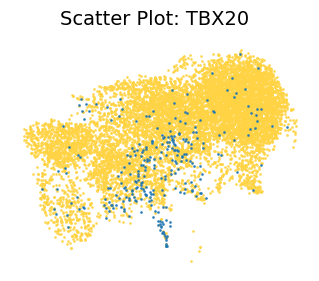

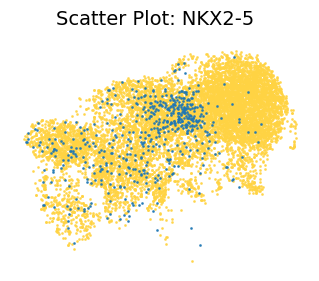

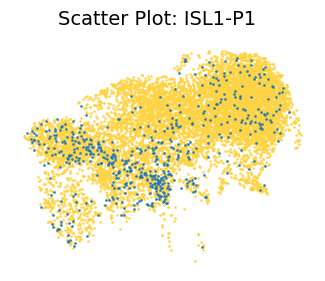

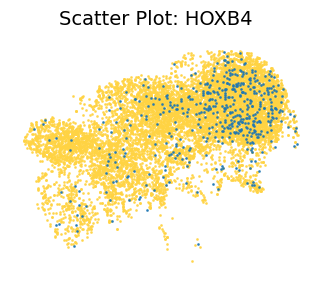

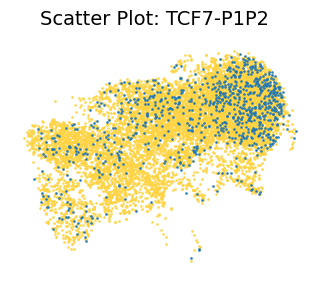

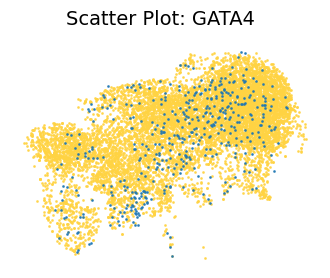

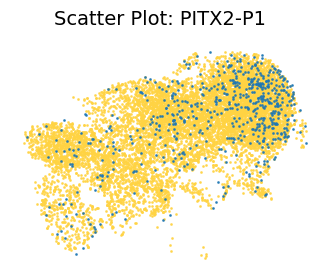

Scatter plots saved in /project/GCRB/Hon_lab/s438217/cNMF/TF_full_cNMF_figure_2_plots/


In [27]:
adata_subset = sc.read("/project/GCRB/Hon_lab/s438217/TF_perturb_Seq_Full/adata_tf_full_filtered_chikara_targets_all_clear_new_11_3_2024.h5ad",backed = "r")



TF_colname = ["TBX20", "NKX2-5", "ISL1-P1", 'HOXB4', 'TCF7-P1P2', 'GATA4', 'PITX2-P1']

# Set the output directory for the PNG files
output_dir = "/project/GCRB/Hon_lab/s438217/cNMF/TF_full_cNMF_figure_2_plots/"

# Loop through each TF and generate individual scatter plots
for j in TF_colname:
    fig, ax = plt.subplots(figsize=(4, 3))  # Create a new figure and axis for each element in TF_colname

    # Plot "NON-TARGETING" points
    for t in adata_subset.obs.columns:
        if t.startswith("non"):
            example_column2 = list(adata_subset.obs[t])
            indices = np.nonzero(example_column2)[0]
            indices = np.random.choice(indices, size=10000)  # Sample up to 10,000 points
            x = adata_subset.obsm['X_umap'][indices, 0]
            y = adata_subset.obsm['X_umap'][indices, 1]
            ax.scatter(x, y, label="NON-TARGETING", c='#ffd343', s=1, alpha=0.8)

    # Plot points for the current TF
    for i in adata_subset.obs.columns:
        if i.startswith(j):
            example_column1 = list(adata_subset.obs[i])
            indices = np.nonzero(example_column1)[0]
            x = adata_subset.obsm['X_umap'][indices, 0]
            y = adata_subset.obsm['X_umap'][indices, 1]
            ax.scatter(x, y, label=i, s=1, alpha=0.8)

    # Remove axis ticks and gridlines
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.axis('off')
    ax.set_aspect('equal') 
    #ax.legend(fontsize=5)
    ax.grid(False)

    # Add a title to the plot
    fig.suptitle(f"Scatter Plot: {j}", fontsize=14)

    # Save the figure as a PNG file
    output_path = f"{output_dir}{j}_scatter_plot.png"
    fig.savefig(output_path, dpi=300)  # Save with high resolution (300 DPI)
    plt.show()  # Display the UMAP scatter plot
    plt.close(fig)  # Close the figure to free up memory

print(f"Scatter plots saved in {output_dir}")

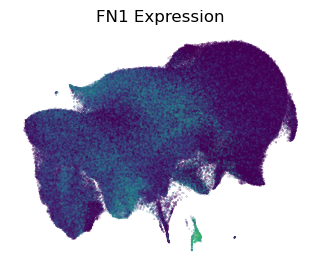

UMAP plot for FN1 saved as /project/GCRB/Hon_lab/s438217/cNMF/TF_full_cNMF_figure_2_plots/FN1_UMAP.png


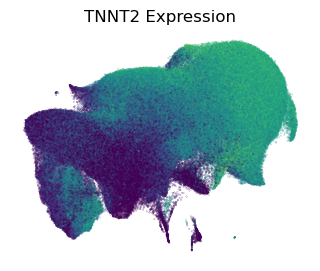

UMAP plot for TNNT2 saved as /project/GCRB/Hon_lab/s438217/cNMF/TF_full_cNMF_figure_2_plots/TNNT2_UMAP.png
Colorbar saved separately as /project/GCRB/Hon_lab/s438217/cNMF/TF_full_cNMF_figure_2_plots/Colorbar.pdf


In [22]:
import os
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np

# Define the output directory
output_dir = "/project/GCRB/Hon_lab/s438217/cNMF/TF_full_cNMF_figure_2_plots/" # Change this to your desired folder path

# Create the directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Define genes to plot
genes = ["FN1", "TNNT2"]

# Extract UMAP coordinates
x = adata_subset.obsm['X_umap'][:, 0]
y = adata_subset.obsm['X_umap'][:, 1]

for gene in genes:
    fig, ax = plt.subplots(figsize=(4, 3))  # Create a new figure for each gene

    # Extract gene expression
    if gene in adata_subset.var_names:
        expression = adata_subset[:, gene].X.toarray().flatten() if hasattr(adata_subset[:, gene].X, "toarray") else adata_subset[:, gene].X.flatten()
    else:
        expression = np.zeros(adata_subset.shape[0])  # If gene not found, fill with zeros

    # Plot UMAP scatter plot
    sc = ax.scatter(x, y, c=expression, cmap="viridis", s=0.02)
    ax.set_title(f"{gene} Expression", fontsize=12)
    
    # Remove axis ticks
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.axis('off')

    # Set equal aspect ratio
    ax.set_aspect('equal')

    # Save the UMAP figure for this gene in the output folder
    umap_output_path = os.path.join(output_dir, f"{gene}_UMAP.png")
    fig.savefig(umap_output_path, dpi=600, bbox_inches='tight')
    plt.show()
    plt.close(fig)  # Close the figure to free memory

    print(f"UMAP plot for {gene} saved as {umap_output_path}")

# Create and save a separate colorbar
fig_cbar, ax_cbar = plt.subplots(figsize=(4, 3))  # New figure for the colorbar
cbar = fig_cbar.colorbar(sc, cax=ax_cbar, orientation='vertical')
cbar.set_label("Expression Level")

# Save the colorbar separately in the output folder
colorbar_output_path = os.path.join(output_dir, "Colorbar.pdf")
fig_cbar.savefig(colorbar_output_path, dpi=600, bbox_inches='tight')
plt.close(fig_cbar)  # Close the colorbar figure

print(f"Colorbar saved separately as {colorbar_output_path}")
